# Lecture 11: Markov Chain Monte Carlo

Joong-Ho Won  
June 2026

In [ ]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] compiler_4.6.0  fastmap_1.2.0   cli_3.6.6       tools_4.6.0    
 [5] htmltools_0.5.9 yaml_2.3.12     rmarkdown_2.31  knitr_1.51     
 [9] jsonlite_2.0.0  xfun_0.58       digest_0.6.39   rlang_1.2.0    
[13] evaluate_1.

In [ ]:
library(ggplot2)

## Introduction

Markov chain Monte Carlo (MCMC) is a collection of methods simulating a
distribution $\pi$ by generating a Markov chain whose limiting
distribution equals $\pi$.

## Review: Markov chain

### Definition

A distcrete time, discrete-state-space Markov chain is a sequence of
random variables $\{X_n\}$ where $X_n \subset S \subset \mathbb{N}$ for
all $n=0, 1, 2,\dotsc$, with
$$    \Pr(X_{n+1} = j \mid X_n = i, X_{n-1} = i_{n-1}, \dotsc ) = \Pr(X_{n+1}=j \mid X_n = i) =: P_{ij}(n)
    .$$
Here, $S$ is called the *state space*, and $P_{ij}$ is called the
(state-) transition probabilty.

- Obviously, $\sum_{j\in S} P_{ij}(n) = 1$, for all $i\in S$.
- $P(n) := (P_{ij}(n))_{i,j \in S}$, transition probability matrix.
- $P(n) = P$ for all $n$, time-homogenity.

#### Example 1. Simple random walk

$$\begin{align*}
\Delta_i &= \begin{cases} +1, & \text{w.p.}~p \\ -1, & \text{w.p.}~1- p \end{cases}
,
\quad
\{\Delta_i\}~\text{i.i.d.}
\\
X_{n+1} &= X_n + \Delta_{n+1} 
,
\quad
X_0 = 0
.
\end{align*}$$

- $P_{i,i+1} = p$, $P_{i,i-1} = 1 - p$, $S = \mathbb{N}$.

#### Example 2. Gambler’s ruin

- $N$: casino’s wealth. $S = \{0, 1, 2 \dotsc, N\}$ (gambler’s wealth)
- $P_{00} = 1$ (gambler’s ruin); $P_{NN} = 1$ (casino’s ruin)
- $P_{i,i+1} = p$, $P_{i,i-1} = 1-p$.

### Chapman-Kolmogorov equation

- For a time-homogeneous Markov chain, let $P^{(n)} = (P_{ij}^{(n)})$,
  $P_{ij}^{(n)} = \Pr(X_{m+n}=j \mid X_m = i)$.
- Then, $P^{(m+n)} = P^{(m)} P^{(n)}$.
- So $P^{(n)} = P^n$.

### Communication classes

- $i \rightarrow j$ (reachable) if $P_{ij}^{(n)} > 0$ for some
  $n \geq 0$.

- $j \rightarrow i$ if $P_{ji}^{(n)}$ for some $n \geq 0$.

- $j \leftrightarrow i$ (communicates) if and only if $i \rightarrow j$
  and $j \rightarrow i$.

- $S$ is partitioned by communication classes

- A Markov chain is called **irreducible** if it has only one
  communication class, i.e., all states communicates.

#### Example

- Random walk: $S = \mathbb{N}$, irreducible.
- Gambler’s ruin: $S = \{0\} \cup \{1, \dotsc, N-1\} \cup \{N\}$.

### Limiting distributions of a Markov chain

> **Note**
>
> Q: Will there be $\pi_j$’s such that
> $\lim_{n\to\infty} P_{ij}^{(n)} = \pi_j$, $\forall i \in S$,
> $\sum_{j\in S}\pi_j = 1$?

If the chain converges to an equillibrium, then
$\lim_{n\to\infty} P_{ij}^{(n)}$ should exist and be independent of of
the starting state.

- Stationary distribution: $\pi = (\pi_j)_{j\in S}$ such that
  $$\pi = \pi P, \quad \mathbf{1}^\top \pi = 1, \quad \pi \geq 0.$$
  - If $\pi^{(0)} = \pi$, then $\pi^{(1)} = \pi^{(0)}P = \pi$,
    $\pi^{(2)} = \pi^{(1)}P = \pi$, …
  - Also called the invariant distribution.
  - If $P_{ij}^{(n)} = (P^n)_{ij} \to \pi_j$, then
    $$\begin{align*}
    \pi &= \lim_{n\to\infty} (P^{n+1})_{i\cdot} = \lim_{n\to\infty} (P^n P)_{i\cdot} 
    \\
    &= 
    \sum_{j\in S}(\lim_{n\to\infty}(P^n)_{ij}) P_{j\cdot} = \sum_{j\in S} \pi_j P_{j\cdot} = \pi P.
    \end{align*}$$
    Thus the limiting distribution is a stationary distribution.
  - Will the stationary disbution uniquely exist?
- Long-run proportion of time that a Markov chain stays at state $j$
  $$\lim_{n\to\infty} \frac{1}{n}\sum_{k=1}^n I\{X_k = j\}$$
  - Does this limit exist? If so, will it coincide with $\pi$?

#### Characteristics of Markov chains

- A *period* of a Markov chain is
  $$d(i) \triangleq GCD\{n: P_{ii}^{n} > 0\}
  .$$
  - A Markov chain is **aperiodic** if $d(i) = 1$ for all $i \in S$;
- Recurrence
  - First return time to state $i$
    $$\tau_{ii} = \begin{cases} \min\{n \geq 1: X_n = i, X_0 = i\}, & ~ \\ \infty, \text{if}~X_n \neq i, \forall n > 0. \end{cases}$$
  - State $i$ is
    - *recurrent* if $\tau_{ii} < \infty$ with probability 1 — the chain
      returns to state $i$ infinitely often.
      - **positive recurrent** if $\operatorname{E}[\tau_{ii}] < \infty$
        (e.g., gambler’s ruin with $p < 1/2$);
      - null recurrent if $\operatorname{E}[\tau_{ii}] = \infty$ (e.g.,
        gambler’s ruin with $p=1/2$).
    - *transient* if $\Pr(\tau_{ii} = \infty) > 0$. (e.g., gambler’s
      ruin with $p > 1/2$)
  - If $i \leftrightarrow j$, then $i$ and $j$ are either recurrent or
    transient at the same time — recurrence is the communication class
    property.
  - For a communication class $C$, all states in $C$ are either
    transient, positive recurrent, or null recurrent.
- Ergodicity: a Markov chain is **ergodic** if it is aperiodic and
  positive recurrent.
  - In a *finite state space*, irreducible Markov chain, all states are
    positive recurrent — aperiodic + irreducible = ergodic.

#### Limit Theorems

1.  An irreducible Markov chain has the *unique* stationary distribution
    if and only if it is positive recurrent.

2.  If a Markov chain is irreducible and ergodic, then

    1.  the limit $\lim_{n\to\infty} P_{ij}^{(n)} = \pi_j$ exists,
        *independent of* $i$;
    2.  $\pi = (\pi_j)_{j\in S}$ uniquely satisfies $\pi = \pi P$,
        $\mathbf{1}^\top \pi = 1$, $\pi \geq 0$;
    3.  $\pi_j = \lim_{n\to\infty}\frac{1}{n}\sum_{k=1}^n I\{X_k=j \mid X_0=i\} = 1/\operatorname{E}[\tau_{jj}]$.

3.  For an irreducible, aperiodic Markov chain, if $\pi$ is such that
    $\pi = \pi P$, $\mathbf{1}^\top \pi = 1$, $\pi \geq 0$, then
    $\lim_{n\to\infty} P_{ij}^{(n)} = \pi_j$, and the chain is positive
    recurrent hence ergodic.

#### Ergodic Theorem

- Let $\{X_n\}$ be a irreducible, ergodic Markov chain whose stationary
  distribution is $\pi$. Then, for any function $g$ such that
  $\operatorname{E}_{\pi}[|g(X)|] < \infty$ where $X \sim \pi$, we have
  $$\frac{1}{n}\sum_{k=1}^n g(X_k) \stackrel{n\to\infty}{\to} \operatorname{E}_{\pi}[g(X)]$$
  with probabilty 1.

- The ergodic theorem extends the strong law of large numbers from
  i.i.d. sequences to Markov chains.

- Thus we can extend Monte Clarlo integration to Markov (non-i.i.d.)
  sequences — Markov chain Monte Carlo

### MCMC sampling strategy

- Construct an irreducible, aperiodic, and positive recurrent Markov
  chain for which the stationary distribution equals the target
  distribution $f$.

- By sampling from this MC, expectations of functions of random variable
  $X \sim f$ can be reliably estimated.

#### Detailed balance condition

- If a homogeneous MC satisfies the stronger condition
  $$\pi_i P_{ij} = \pi_j P_{ji}
  ,$$
  then $\pi = (\pi_i)_{i\in S}$ is a stationary distribution of the MC.
  (Why?)

- In fact such a Markov chain is reversible because the joint
  distribution of the chain is the same whether the chain is run forward
  or backward.

### Extension to continuous state space

- Continuous-state-space, time-homogeneous MC
  $$P_{ij} \rightarrow K(x, y)$$
  where $K(x, y) = P_{X_{n+1}\mid X_n}(y \mid x)$ is the *transition
  kernel* such that $\int_S K(x, y) dy = 1$.

- Irreducibility, recurrence, stationary distribution, etc. are defined
  analogously as the discrete state space case.

- Detailed balance condition:
  $$\pi(x) K(x, y) = \pi(y) K(y, x)
  \implies
  \pi(y) = \int_S \pi(x) K(x, y) dx$$

- Limit theorems also hold analogously.

## Metropolis-Hastings algorithm

- Metropolis N, Rosenbluth AW, Rosenbluth MN, Teller AH, Teller E
  (1953). “Equation of State Calculations by Fast Computing
  Machines”. J. Chem. Phys. 21 (6): 1087.

- Hastings WK (1970). “Monte Carlo Sampling Methods Using Markov Chains
  and Their Applications”. Biometrika. 57 (1): 97–109.

### The algorithm

For $t= 0, 1, \dotsc$,

1.  Sample a condidate alue $\tilde{X}$ from a *proposal distribution*
    $g(\cdot \mid X^{(t)})$.

2.  Compute the Metropolis-Hastings ratio
    $$R(X^{(t)}, \tilde{X}) = \frac{f(\tilde{X})g(X^{(t)}\mid \tilde{X})}{f(X^{(t)})g(\tilde{X}\mid X^{(t)})}
    .$$

3.  Sample a value for $X^{(t+1)}$ such that
    $$X^{(t+1)} = \begin{cases} \tilde{X}, & \text{w.p.}~\min\{R(X^{(t)}, \tilde{X}), 1\},
        \\
        X^{(t)}, & \text{otherwise}. 
    \end{cases}$$

    - $\alpha(X^{(t)}, \tilde{X}) = \min\{R(X^{(t)}, \tilde{X}), 1\}$ is
      the acceptance probability of the proposal.

**Note**. The MH ratio $R(X^{(t)}, \tilde{X})$ is well-defined for each
$t$ if we draw $X^{(0)}$ from some starting distribution, with
requirement $f(X^{(0)}) > 0$.

- Metripolis (1953): $g(u \mid v) = g(v \mid v)$ (symmetric)

### Stationary distribution

- Transition probability kernel
  $$K(x, y) = \alpha(x, y)g(y\mid x) + (1 - r(x))\delta(y - x)$$
  where
  $$\alpha(x, y) = \min\left\{1, \frac{f(y)g(x\mid y)}{f(x)g(y\mid x)}\right\}
  ,
  \quad
  r(x) = \int \alpha(x, y) g(x \mid y) dy$$
  and the $\delta$ is the Dirac delta function.

<figure>
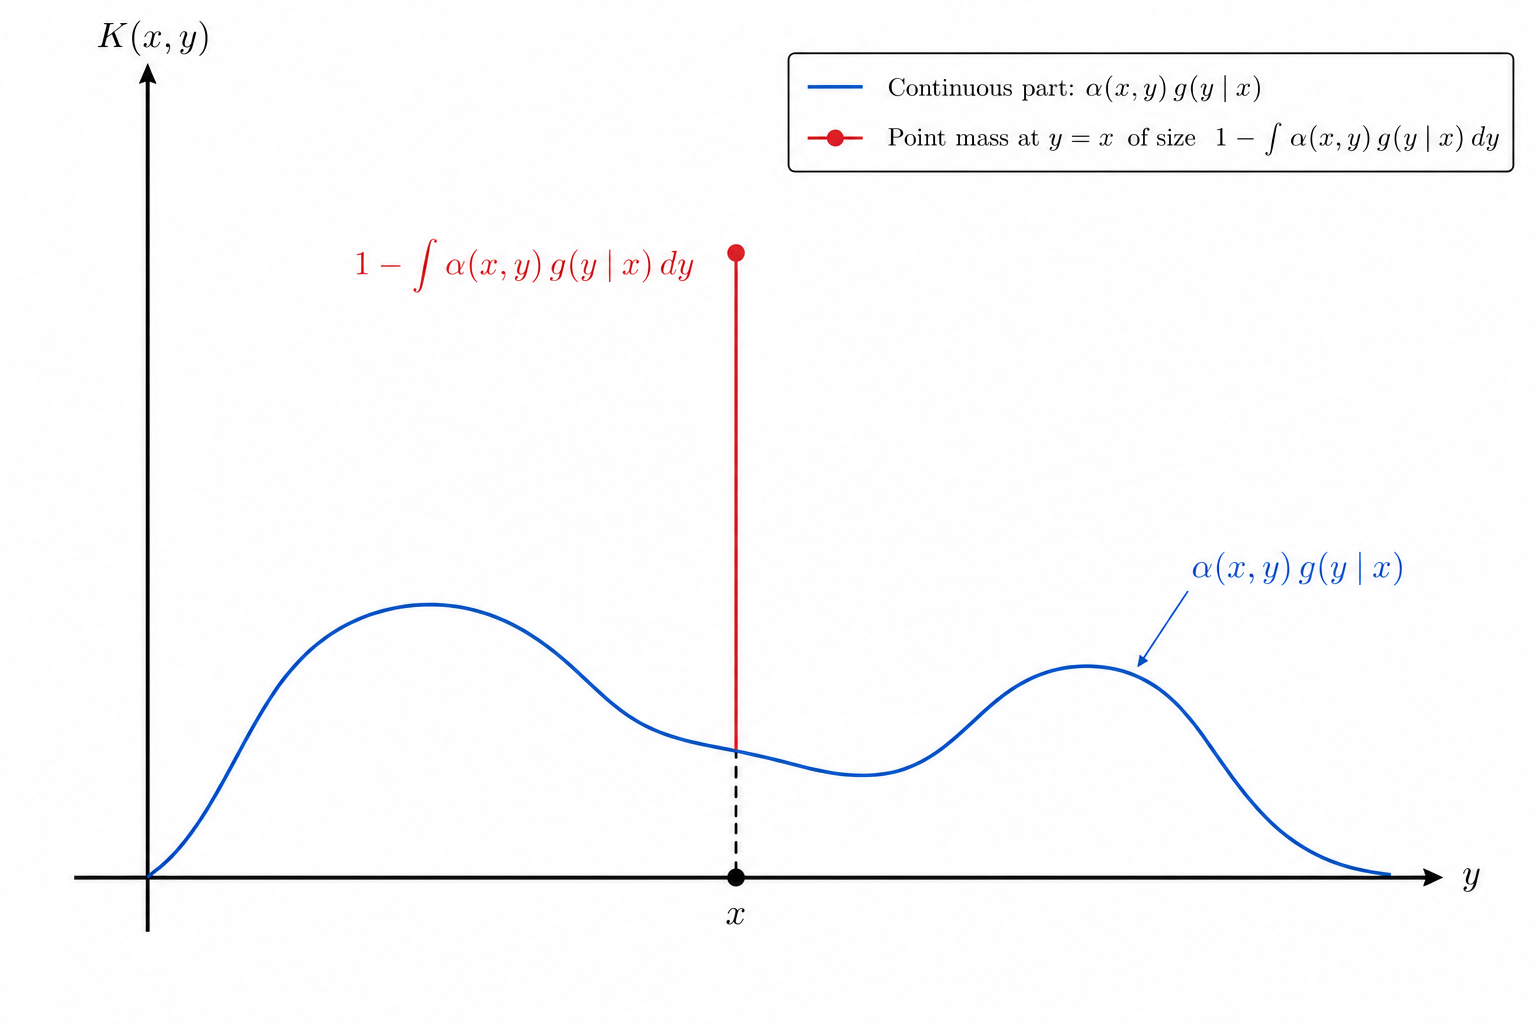
<figcaption aria-hidden="true">Metropolis-Hastings kernel (<span
class="math inline"><em>x</em></span> fixed)</figcaption>
</figure>

- Note

  1.  $f(x)\alpha(x, y)g(y\mid x) = \min\{f(x)g(y \mid x), f(y)g(x \mid y)\} = f(y)\alpha(y, x)g(x \mid y)$;
  2.  $f(x)(1 - r(x))\delta(y - x) = f(y)(1 - r(y))\delta(x - y)$ by the
      property of Dirac delta.

- It follows $f(x)K(x, y) = f(y)K(y, x)$, the detailed balance equation.

- Therefore $f$ is the stationary distribution of this MC.

- Irreducibility, aperiodicity, positive recurrence of this MC depends
  on $g(\cdot\mid\cdot)$ and the user must check.

- Aperiodicity usually holds since $\Pr(X^{(t+1)} = X^{(t)}) > 0$
  (rejection probability).

- Irreducibility holds if $f(x) > 0$ for all $x \in S$ and the chain
  defined by the kernal $\tilde{K}(x, y) = g(y|x)$ is irreducible.

#### Example: discrete Metropolis

- For each state $i$, assume that $g(i, i) > 0$ and there exists a
  neighboring state $j$ ($g(j\mid i) > 0$) such that $f(i) > f(j)$. Then
  $$\alpha(i, j) = \min\{ f(j)/f(i), 1\} < 1
  .$$
  Thus
  $$r(i) = \sum_{j'}\alpha(i, j')g(j'\mid i) < \sum_{j'} g(j'\mid i) = 1$$
  and $K(i, i) = \alpha(i, i)g(i, i) + 1 - r(i) > 0$.

- Therefore $d(i) = 1$.

In [ ]:
MH_sampler <- function(target_log_density, proposal,
                       N = 10000, burn_in = 1000, 
                       thin = 1 ) {
  theta <- numeric(N)
  theta[1] <- 0 # initialize
  acc <- 0L # accepted?

  for (t in 2:N) {
    current <- theta[t - 1]
    theta_tilde <- proposal$sample(1)

    # log acceptance ratio:
    log_alpha <- target_log_density(theta_tilde) +
      proposal$log_density(current, theta_tilde) -
      target_log_density(current) -
      proposal$log_density(theta_tilde, current)

    if (log(runif(1)) < min(0, log_alpha)) {
      theta[t] <- theta_tilde
      acc <- acc + 1L
    } else {
      theta[t] <- current
    }
  }

  # Thin and discard burn-in (more on this later)
  list(
    theta = theta[seq(from = burn_in + 1, to = N, by = thin)],
    theta_all = theta,
    acceptance_rate = acc / (N - 1),
    target_log_density = target_log_density
  )
}

#### Example: posterior sampling

- Goal: We want to sample from the posterior density
  $p_{\Theta\mid Y}(\theta \mid y)$, with $p_{\Theta}(\theta)$ a prior.

- Difficulty:
  $p_{\Theta\mid Y}(\theta \mid y) = c p_{Y\mid\Theta}(y\mid \theta)p_{\Theta}(\theta)$,
  $c > 0$ unknown.

- Solution: Metropolis-Hastings MCMC

  - Target distribution: $f(\cdot) = p_{\Theta\mid Y}(\cdot \mid y)$
  - M-H ratio
    $$\begin{align*}
    R(\theta^{(t)}, \tilde{\theta})
    &=
    \frac{f(\tilde{\theta})g(\theta^{(t)} \mid \tilde{\theta})}{f(\theta^{(t)})g(\tilde{\theta} \mid \theta^{(t)})}
    =
    \frac{p_{\Theta\mid Y}(\tilde{\theta}\mid y)g(\theta^{(t)}\mid \tilde{\theta})}{p_{\Theta\mid Y}(\theta^{(t)}\mid y)g(\tilde{\theta}\mid \theta^{(t)})}
    \\
    &=
    \frac{c p_{Y\mid\Theta}(y\mid \tilde{\theta})p_{\Theta}(\tilde{\theta})g(\theta^{(t)}\mid\tilde{\theta})}{c p_{Y\mid\Theta}(y\mid \theta^{(t)})p_{\Theta}(\theta^{(t)})g(\tilde{\theta}\mid\theta^{(t)})}
    =
    \frac{p_{Y\mid\Theta}(y\mid \tilde{\theta})p_{\Theta}(\tilde{\theta})g(\theta^{(t)}\mid\tilde{\theta})}{p_{Y\mid\Theta}(y\mid \theta^{(t)})p_{\Theta}(\theta^{(t)})g(\tilde{\theta}\mid\theta^{(t)})}
    \end{align*}$$
    which is independent of $c$!

- Independent chain: $g(\cdot, *) = p_{\Theta}(\cdot)$

  - M-H ratio
    $$\begin{align*}
    R(\theta^{(t)}, \tilde{\theta})
    &=
    \frac{p_{Y\mid\Theta}(y\mid \tilde{\theta})p_{\Theta}(\tilde{\theta})g(\theta^{(t)}\mid\tilde{\theta})}{p_{Y\mid\Theta}(y\mid \theta^{(t)})p_{\Theta}(\theta^{(t)})g(\tilde{\theta}\mid\theta^{(t)})}
    =
    \frac{p_{Y\mid\Theta}(y\mid \tilde{\theta})p_{\Theta}(\tilde{\theta})p_{\Theta}(\theta^{(t)})}{p_{Y\mid\Theta}(y\mid \theta^{(t)})p_{\Theta}(\theta^{(t)})p_{\Theta}(\tilde{\theta})}
    \\
    &=
    \frac{p_{Y\mid\Theta}(y\mid \tilde{\theta})}{p_{Y\mid\Theta}(y\mid \theta^{(t)})}
    \end{align*}$$
    only depends on the likelihood.

#### Example: Binomial-logit mixture

Suppose $x$ is a random sample from a Binomial distribution with $n$
trials and success probability $p=\frac{e^{\theta}}{1 + e^{\theta}}$.
Suppose the prior on $\theta$ is $N(0, \sigma^2)$.

- Prior density:
  $f_{\Theta}(\theta) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\theta^2/(2\sigma^2)}$.
- Likelihood: $f_{X|\Theta}(x|\theta) = \binom{n}{x}p^x(1 - p)^{n-x}$,
  with $p=\frac{e^{\theta}}{1 + e^{\theta}}$.
- Posterior density:
  $$\begin{align*}
    f_{\Theta|X}(\theta|x) &= \frac{f_{X|\Theta}(x | \theta)f_{\Theta}(\theta)}{\int_{-\infty}^{\infty}f_{X|\Theta}(x | \theta')f_{\Theta}(\theta')d\theta'}
    = \frac{p(\theta)^x[1-p(\theta)]^{n-x}e^{-\theta^2/(2\sigma^2)}}{\int_{-\infty}^{\infty}p(\theta)^x[1-p(\theta)]^{n-x}e^{-\theta^2/(2\sigma^2)}d\theta}
    \\
    &= \frac{e^{\theta x}[1+e^{\theta}]^{-n}e^{-\theta^2/(2\sigma^2)}}{\int_{-\infty}^{\infty}e^{\theta x}[1+e^{\theta}]^{-n}e^{-\theta^2/(2\sigma^2)}d\theta}
  \end{align*}$$

In [ ]:
log_binom_logit_posterior <- function(x, n, sigma) {
  function(theta) {
    p <- plogis(theta)  # numerically stable logistic transform
    dbinom(x, size = n, prob = p, log = TRUE) +
        dnorm(theta, mean = 0, sd = sigma, log = TRUE)
  }
}
independent_normal_proposal <- function(prop_mean = 0, 
                                        prop_sd = 1) {
  list(
    sample = function(n) { rnorm(n, mean = prop_mean, 
                                 sd = prop_sd) },
    log_density = function(theta, phi) { # discard 2nd arg
        dnorm(theta, mean = prop_mean, sd = prop_sd, 
              log = TRUE)
    }
   )
}
plot_posterior <- function(posterior_df, target_log_density) {
  # Create a grid of theta values
  theta_grid <- seq(min(posterior_df$theta) - 1,
                    max(posterior_df$theta) + 1,
                    length.out = 1000)
  # Unnormalized posterior
  log_post <- target_log_density(theta_grid)
  post <- exp(log_post - max(log_post)) # to avoid overflow

  posterior_curve <- data.frame(theta = theta_grid, 
                                density = post)

  # Normalize numerically
  dx <- theta_grid[2] - theta_grid[1]
  posterior_curve$density <- posterior_curve$density /
    sum(posterior_curve$density * dx)

  # Plot MCMC histogram against posterior curve
  ggplot() +
  geom_histogram(data = posterior_df,
    aes(x = theta, y = after_stat(density)),
    bins = 40, fill = "skyblue",
    color = "black", alpha = 0.5
  ) +
  geom_line(data = posterior_curve,
    aes(x = theta, density), color = "red",
    linewidth = 1.2
  ) +
  labs(
    title = "Independent MH Samples vs. Posterior Density",
    x = expression(theta),
    y = "Density"
  ) +
  theme_minimal(base_size = 14)
}

In [ ]:
set.seed(2020)
sigma <- 10
my_prop <- independent_normal_proposal(prop_sd = sigma)
my_target1 <- log_binom_logit_posterior(x = 18, n = 20, 
                                        sigma = sigma)
system.time(
  fit1 <- MH_sampler(target_log_density = my_target1,
        proposal = my_prop, N = 20000, burn_in = 2000,
        thin = 5)
)

   user  system elapsed 
  0.297   0.011   0.308 

Acceptance rate =  0.09155458 , 
    Sample size =  3600 

   user  system elapsed 
  0.278   0.000   0.277 

Acceptance rate =  0.02965148 , 
    Sample size =  3600 

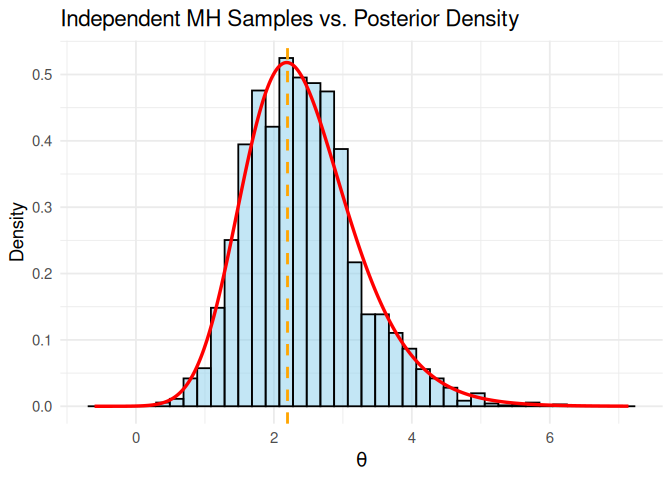

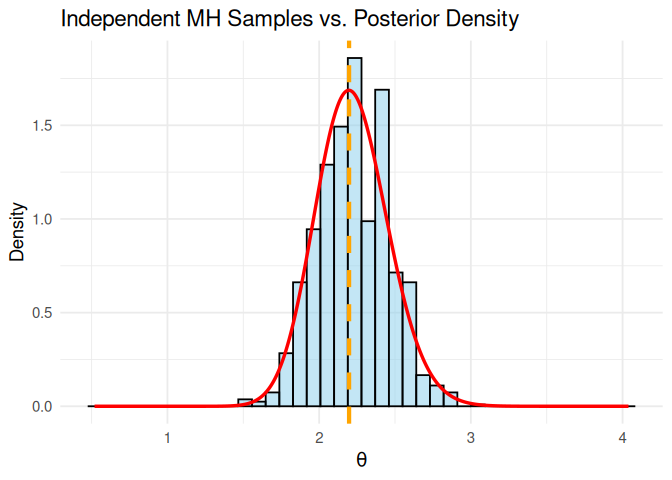

In [ ]:
p_mle <- 18/20; theta_mle = log(p_mle/(1-p_mle))
p1 <- plot_posterior(posterior_df1, target_log_density = my_target1)
p1 + geom_vline(xintercept = theta_mle, linetype = "dashed", 
                linewidth = 1, color = "orange")

## Gibbs sampler

- For a multidimensional target distribution with a Cartesian product
  state space, *sequentially* sample from univariate conditional
  distributions, which is often of closed form.

- Let $X = (X_1, \dotsc, X_p)$ and
  $X_{-i} = (X_1, \dotsc, X_{i-1}, X_{i+1}, \dotsc, X_p)$.

- Generate
  $$\begin{align*}
  X_1^{(t+1)} &\sim f_{X_1 \mid X_{-1}}(\cdot \mid X_2^{(t)}, X_3^{(t)}, \dotsc, X_p^{(t)})
  \\
  X_2^{(t+1)} &\sim f_{X_2 \mid X_{-2}}(\cdot \mid X_1^{(t+1)}, X_3^{(t)}, \dotsc, X_p^{(t)})
  \\
  & \vdots
  \\
  X_{p-1}^{(t+1)} &\sim f_{X_{p-1} \mid X_{-(p-1)}}(\cdot \mid X_2^{(t+1)}, \dotsc, X_{p-2}^{(t+1)}, X_p^{(t)})
  \\
  X_p^{(t+1)} &\sim f_{X_p \mid X_{-p}}(\cdot \mid X_1^{(t+1)}, X_2^{(t+1)}, \dotsc, X_{p-1}^{(t)})
  \end{align*}$$
  cf. Gauss-Seidel.

#### Example: bivariate normal

- Target distribution:
  $$\begin{pmatrix} X_1 \\ X_2 \end{pmatrix} \sim 
  N\left( \begin{pmatrix} 0 \\ 0 \end{pmatrix}, \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}\right)$$

- $X_1 \mid \{X_2 = x_2\} \sim N(\rho x_2, 1 - \rho^2)$,
  $X_2 \mid \{X_1 = x_1\} \sim N(\rho x_1, 1 - \rho^2)$.

- Therefore, sample $X_1^{(t+1)} \sim N(\rho X_2^{(t)}, 1 - \rho^2)$ and
  $X_2^{(t+1)} \sim N(\rho X_1^{(t+1)}, 1 - \rho^2)$.

In [ ]:
Rgibbs <- function(N, thin, rho=0) {
  mat <- matrix(0, nrow=N, ncol=2)
  x <- y <- 0
  for (i in 1:N) {
    for (j in 1:thin) {
      x <- rnorm(1, rho * y, sqrt(1 - rho * rho))
      y <- rnorm(1, rho * x, sqrt(1 - rho * rho))
    }
    mat[i,] <- c(x, y)
  }
  df <- as.data.frame(mat)
  names(df) <- c("x1", "x2")
  df
}
set.seed(2020)
system.time(gibbssamp <- Rgibbs(10000, 500, rho = 0.5))

   user  system elapsed 
 10.076   0.000  10.076 

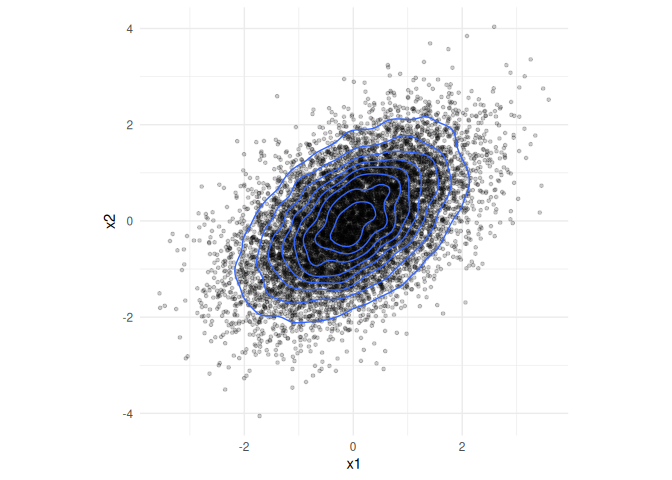

In [ ]:
ggplot(gibbssamp, aes(x=x1, y=x2)) + 
    geom_point(size = 1, alpha=0.2) + 
geom_density2d() + theme_minimal() + theme(aspect.ratio = 1) 

### Relation with Metropolis-Hastings

- At time $t+1$ and for cooridnate $i$, we sample
  $$\tilde{x}_i \sim f_{X_{i} \mid X_{-i}}(\cdot \mid x_{-i}^{(t)})
  ,$$
  where
  $x_{-i}^{(t)} = (x_1^{(t+1)}, \dotsc, x_{i-1}^{(t+1)}, x_{i+1}^{(t)}, \dotsc, x_p^{(t)})$.

- Construct
  $\tilde{x} = (x_1^{(t+1)}, \dotsc, x_{i-1}^{(t+1)}, \tilde{x}_i, x_{i+1}^{(t)}, \dotsc, x_p^{(t)})$.
  This is the proposed sample for the target joint $f$.

- Let
  $x^{(t)} = (x_1^{(t+1)}, \dotsc, x_{i-1}^{(t+1)}, x_i^{(t)}, x_{i+1}^{(t)}, \dotsc, x_p^{(t)})$.
  Then we see
  $$\tilde{x}\mid  x^{(t)}
  \sim g_i( \cdot \mid x^{(t)})
  = f_{X_i\mid X_{-i}}(\tilde{x}_i \mid x_{-i}^{(t)})\delta(\tilde{x}_{-i} - x_{-i}^{(t)})
  =
  \begin{cases}
      f_{X_i\mid X_{-i}}(\tilde{x}_i \mid x_{-t}^{(i)}), \text{if}~\tilde{x}_{-i} = x_{-i}^{(t)} \\
      0, \text{otherwise}.
  \end{cases}$$
  So the proposal density is
  $$g_i(x \mid y) = f_{X_{i}\mid X_{-i}}(x_i \mid y_{-i})\delta(x_{-i} - y_{-i})
  .$$

<figure>
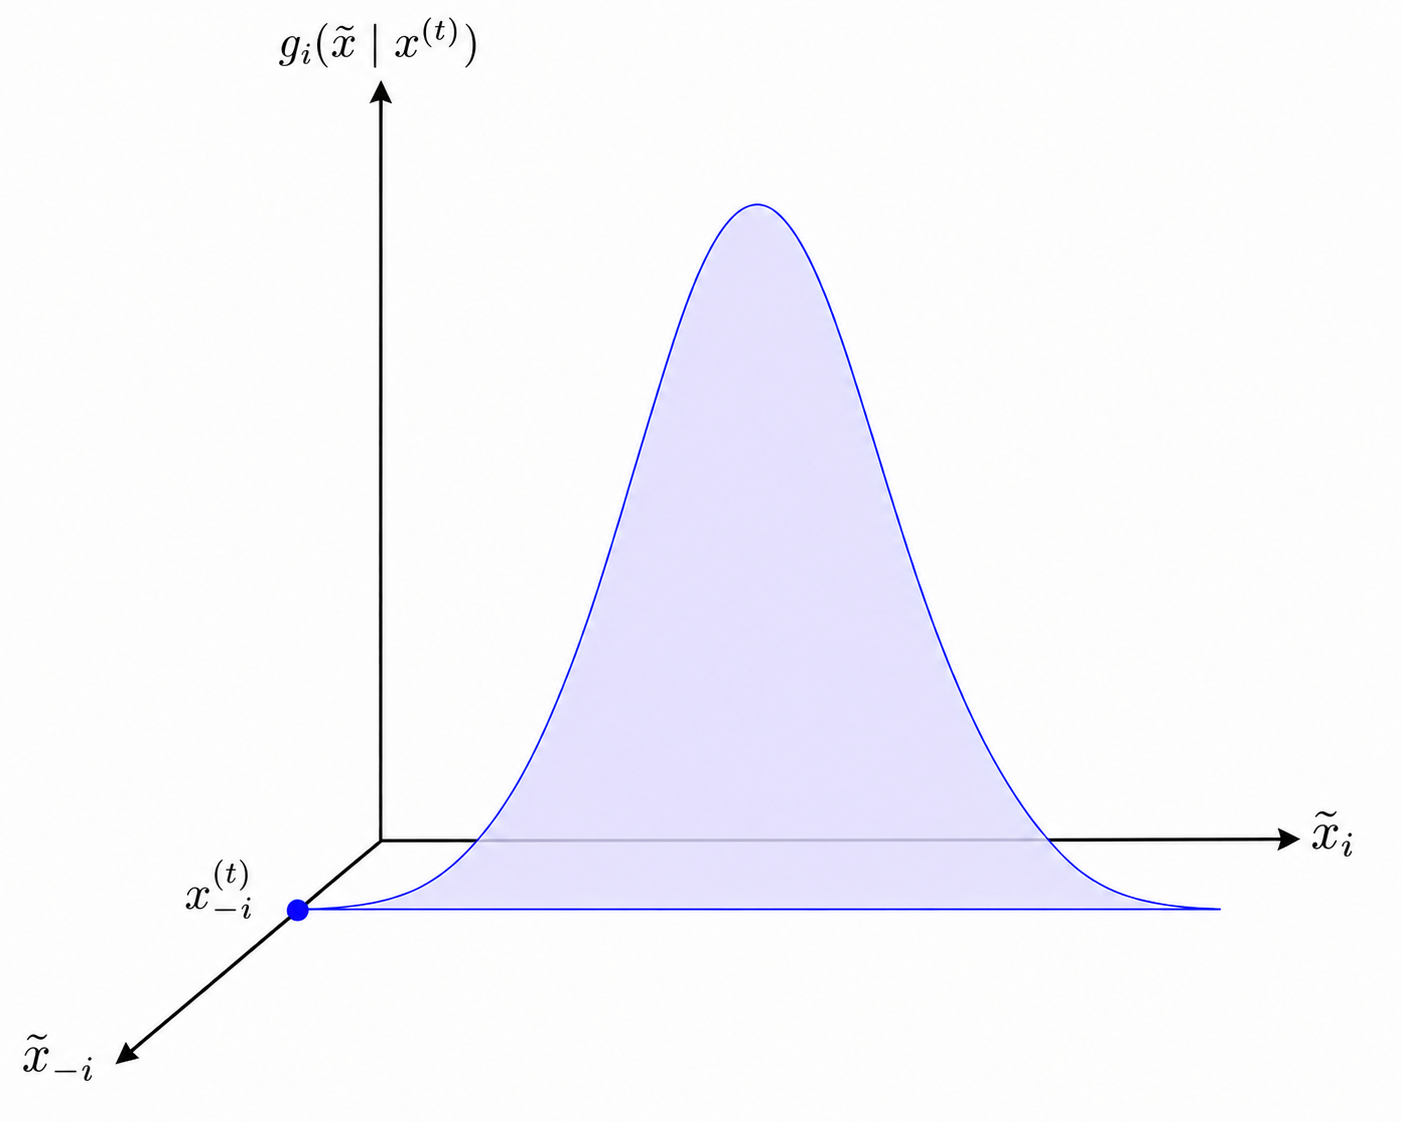
<figcaption aria-hidden="true">Gibbs proposal density</figcaption>
</figure>

- M-H ratio:
  $$\begin{align*}
  R(x^{(t)}, \tilde{x})
  &=
  \frac{f(\tilde{x})g_i(x^{(t)} \mid \tilde{x})}{f(x^{(t)})g_i(\tilde{x} \mid x^{(t)})}
  \\
  &=
  \frac{%
  f_{X_{-i}}(\tilde{x}_{-i})f_{X_i\mid X_{-i}}(\tilde{x}_i\mid \tilde{x}_{-i})f_{X_i\mid X_{-i}}(x_i^{(t)}\mid \tilde{x}_{-i})\delta(x_{-i}^{(t)}-\tilde{x}_{-i})%
  }{%
  f_{X_{-i}}(x_{-i}^{(t)})f_{X_i\mid X_{-i}}(x_i^{(t)}\mid x_{-i}^{(t)})f_{X_i\mid X_{-i}}(\tilde{x}_i\mid x_{-i}^{(t)})\delta(\tilde{x}_{-i}-x_{-i}^{(t)})%
  }
  \\
  &=
  \frac{%
  f_{X_{-i}}(x_{-i}^{(t)})f_{X_i\mid X_{-i}}(\tilde{x}_i\mid x_{-i}^{(t)})f_{X_i\mid X_{-i}}(x_i^{(t)}\mid x_{-i}^{(t)})%
  }{%
  f_{X_{-i}}(x_{-i}^{(t)})f_{X_i\mid X_{-i}}(x_i^{(t)}\mid x_{-i}^{(t)})f_{X_i\mid X_{-i}}(\tilde{x}_i\mid x_{-i}^{(t)})
  }
  \\
  &=
  1
  ,
  \end{align*}$$
  since $\tilde{x}_{-i} = x_{-i}^{(t)}$ with probability 1.

- So the Gibbs sampler is a M-H sampler with a *time-varying* proposal
  distribution, whose proposal is *always accepted*.

#### Example: Ising model

- A mathematical model of ferromagnetism in statistical mechanics.

- $p$ elementary particles equally spaced around the boundary of the
  unit circle (periodic boundary condition)

- Each particle $i$ can have a state
  $$x_i = \begin{cases} 1, &\text{spin up} \\
      -1, &\text{spin down}
  \end{cases}$$
  ($x_{p+1} = x_1$).

- The Gibbs distribution of the state of the system
  $x = (x_1, \dotsc, x_p)$:
  $p(x) = \frac{1}{Z} \exp\left(\beta\sum_{j=1}^p x_j x_{j+1}\right)$,
  $\beta > 0$.

  - States like $(1, 1, \dotsc, 1)$ is favored over
    $(1, -1, 1, \dotsc, 1, -1, 1)$.

- Normalizing constant
  $Z = \sum_{x_1=-1}^1\sum_{x_2=-1}^1\dotsb\sum_{x_p=-1}^1 \exp\left(\beta\sum_{j=1}^p x_j x_{j+1}\right)$,
  sum of $2^p$ terms.

- Gibbs sampling: choose component $i$ and sample
  $$x_i^{(t+1)} = 
  \begin{cases}
  -x_i^{(t)}, &
  \text{w.p.}~
  \frac{\exp(\beta(-x_{i-1}x_i - x_ix_{i+1}))}{\exp(\beta(x_{i-1}x_i+x_ix_{i+1}))+\exp(\beta(-x_{i-1}x_i - x_ix_{i+1}))}
  =
  \frac{1}{1 + \exp(2\beta(x_{i-1}x_i + x_ix_{i+1}))}
  \\
  x_i^{(t)}, &
  \text{w.p.}~
  \frac{\exp(\beta(x_{i-1}x_i + x_ix_{i+1}))}{\exp(\beta(x_{i-1}x_i+x_ix_{i+1}))+\exp(\beta(-x_{i-1}x_i - x_ix_{i+1}))}
  =
  \frac{1}{1 + \exp(-2\beta(x_{i-1}x_i + x_ix_{i+1}))}
  .
  \end{cases}$$
  (logistic regression)

## Practical considerations

1.  When does the MC reach the stationary state (mixing)? When does one
    stop?

2.  Usually one discards an initial part of an MCMC sample (burn-in).
    How many burn-ins should be discarded?

3.  i.i.d. sampling

    - Inherently the samples are correlated.
    - Ideally, run $N$ parallel chains and thake only the terminal
      values.
    - Subsample to reduce correlation: $Y_m = X_{mk}$ for some batch
      size $k > 1$ (thinnig)